<a href="https://colab.research.google.com/github/RizkyAditya007/Visi-Komputer/blob/main/jobsheet_02(VK)_Rizky_Aditya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# D1 - Memulai Klasifikasi Gambar dengan Dataset Sederhana

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


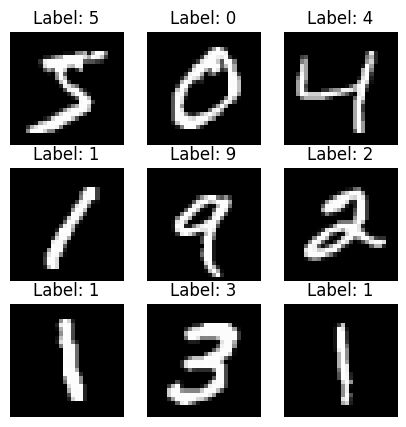

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Tampilkan contoh
plt.figure(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

#Praktikum D2 Klasifikasi Gambar dengan Model Machine Learning Tradisional

In [ ]:
from sklearn import svm
from sklearn.metrics import accuracy_score

# Flatten
x_train_flat = x_train.reshape(len(x_train), -1) / 255.0
x_test_flat = x_test.reshape(len(x_test), -1) / 255.0
 # SVM
clf = svm.SVC(kernel='rbf', gamma='scale')
clf.fit(x_train_flat[:5000], y_train[:5000])  # gunakan subset karena SVM berat
y_pred = clf.predict(x_test_flat)

print("Akurasi:", accuracy_score(y_test, y_pred))

Akurasi: 0.9513


# Praktikum D3 – Membangun CNN Sederhana

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9493 - loss: 0.1742 - val_accuracy: 0.9810 - val_loss: 0.0673
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.9821 - loss: 0.0600 - val_accuracy: 0.9852 - val_loss: 0.0508
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9870 - loss: 0.0407 - val_accuracy: 0.9843 - val_loss: 0.0523
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.9909 - loss: 0.0281 - val_accuracy: 0.9867 - val_loss: 0.0479
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9931 - loss: 0.0216 - val_accuracy: 0.9860 - val_loss: 0.0550


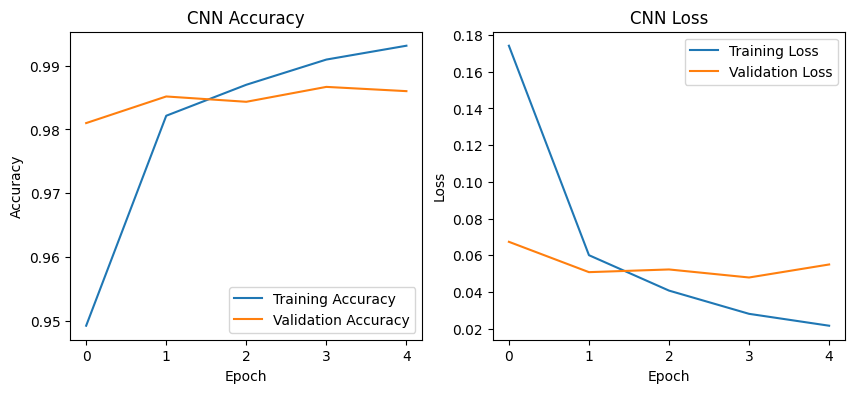

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

x_train_cnn = x_train.reshape(-1,28,28,1) / 255.0
x_test_cnn = x_test.reshape(-1,28,28,1) / 255.0

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train_cnn, y_train, epochs=5, validation_split=0.1)

# ===== Plot history =====
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Saving Foto angka.jpg to Foto angka (2).jpg


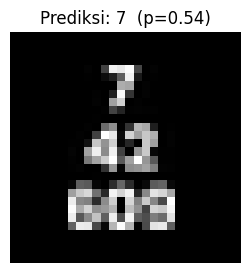

Refleksi untuk gambar 'Foto angka (2).jpg':
Prediksi dengan kepercayaan rendah (0.54). Ini mungkin disebabkan oleh gambar yang berisi banyak angka, pencahayaan yang kurang optimal, atau ketebalan tulisan yang bervariasi. Model ini mungkin kesulitan mengenali pola yang kompleks atau berbeda dari data latih MNIST.


Rekap Prediksi (CNN):
- Foto angka (2).jpg -> 7 (p=0.544)


In [28]:
from google.colab import files
uploaded = files.upload()  # pilih 1 atau lebih file gambar (jpg/png)

# ===== 2) Utilitas Preprocess agar mirip MNIST (28x28, putih-di-atashitam) =====
import numpy as np
from PIL import Image, ImageOps
def preprocess_to_mnist_28x28(img_pil):
    """
    Langkah:
- Konversi ke grayscale
- Auto-contrast
- (Opsional) invert bila latar terang (agar digit jadi putih, latar jadi gelap seperti MNIST)
- Crop ke bounding box digit
- Resize mempertahankan rasio ke (20x20), lalu pad ke (28x28)
- Normalisasi ke [0,1] dan tambah axis channel
    """
    # Grayscale + autocontrast
    img = img_pil.convert('L')
    img = ImageOps.autocontrast(img)

    arr = np.array(img).astype(np.uint8)
    # Jika rata-rata terang (kertas putih), invert supaya digit menjadi putih di atas latar gelap (gaya MNIST)
    if arr.mean() > 127:
        img = ImageOps.invert(img)
        arr = np.array(img)

    # Binarisasi ringan untuk cari bbox digit
    thr = np.mean(arr) * 0.8  # ambang adaptif sederhana
    mask = arr > thr
    if mask.any():
        ys, xs = np.where(mask)
        y0, y1 = ys.min(), ys.max()
        x0, x1 = xs.min(), xs.max()
        img = img.crop((x0, y0, x1+1, y1+1))

    # Resize ke 20x20 dengan aspect ratio
    img.thumbnail((20, 20), Image.Resampling.LANCZOS)
    w, h = img.size

    # Pad ke 28x28 dan center
    canvas = Image.new('L', (28, 28), color=0)
    canvas.paste(img, ((28 - w)//2, (28 - h)//2))

    # Normalisasi ke [0,1]
    arr = np.array(canvas).astype('float32') / 255.0
    # Tambah channel dim (28,28,1)
    arr = arr[..., None]
    return canvas, arr

import matplotlib.pyplot as plt
results = []
for fname in uploaded.keys():
    img_pil = Image.open(fname)
    disp, x = preprocess_to_mnist_28x28(img_pil)   # disp: PIL untuk ditampilkan, x: (28,28,1)

    # Convert 1-channel (grayscale) to 3-channel by stacking
    # This is necessary as the model (e.g., VGG16) expects 3-channel input.
    x_3_channel = np.concatenate([x, x, x], axis=-1)

    # Resize image from 28x28 to 32x32 to match model input shape (VGG16 on CIFAR-10)
    # Convert the 3-channel numpy array back to PIL Image for resizing
    # Squeeze is used to remove the last dimension if it's 1 (e.g., (28,28,1) -> (28,28))
    # but here x_3_channel is (28,28,3) so no squeeze.
    # We need to reshape for PIL if it's 3D.
    img_to_resize = Image.fromarray((x_3_channel * 255).astype(np.uint8))
    img_resized = img_to_resize.resize((32, 32), Image.Resampling.LANCZOS)

    # Convert back to numpy array and normalize
    x_final = np.array(img_resized).astype('float32') / 255.0
    # Ensure it has 3 channels if Image.fromarray/resize changed it (it usually keeps 3)
    if len(x_final.shape) == 2:
        x_final = np.stack([x_final, x_final, x_final], axis=-1)

    x_batch = np.expand_dims(x_final, axis=0) # (1,32,32,3)

    probs = model.predict(x_batch, verbose=0)[0]   # shape (10,)
    pred = int(np.argmax(probs))
    conf = float(np.max(probs))

    results.append((fname, pred, conf))

    # Tampilkan hasil
    plt.figure(figsize=(3,3))
    plt.imshow(disp, cmap='gray')
    plt.title(f"Prediksi: {pred}  (p={conf:.2f})")
    plt.axis('off')
    plt.show()

    # Refleksi
    print(f"Refleksi untuk gambar '{fname}':")
    if conf < 0.7:
        print(f"Prediksi dengan kepercayaan rendah ({conf:.2f}). Ini mungkin disebabkan oleh gambar yang berisi banyak angka, pencahayaan yang kurang optimal, atau ketebalan tulisan yang bervariasi. Model ini mungkin kesulitan mengenali pola yang kompleks atau berbeda dari data latih MNIST.")
    else:
        print(f"Prediksi dengan kepercayaan tinggi ({conf:.2f}). Ini menunjukkan model cukup yakin dengan prediksinya. Pastikan bahwa gambar tersebut hanya berisi satu digit dan diproses dengan baik.")
    print("\n")

# Rekap ringkas
print("Rekap Prediksi (CNN):")
for r in results:
    print(f"- {r[0]} -> {r[1]} (p={r[2]:.3f})")

#Praktikum D4 Eksperimen dengan Dataset Lebih Kompleks (CIFAR-10)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1204s 7us/step


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 35s 25ms/step - accuracy: 0.4446 - loss: 1.5385 - val_accuracy: 0.5560 - val_loss: 1.2617
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 33s 23ms/step - accuracy: 0.5917 - loss: 1.1650 - val_accuracy: 0.6246 - val_loss: 1.0823
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 33s 23ms/step - accuracy: 0.6404 - loss: 1.0312 - val_accuracy: 0.6408 - val_loss: 1.0416
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 33s 23ms/step - accuracy: 0.6694 - loss: 0.9454 - val_accuracy: 0.6634 - val_loss: 0.9857
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 32s 23ms/step - accuracy: 0.6968 - loss: 0.8751 - val_accuracy: 0.6590 - val_loss: 0.9704
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 42s 23ms/step - accuracy: 0.7117 - loss: 0.8268 - val_accuracy: 0.6916 - val_loss: 0.9189
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 40s 28ms/step - accuracy: 0.7320 - loss: 0.7749 - val_accuracy: 0.6928 - val_loss: 0.9096
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 33s 23ms/step - accuracy: 0.7463 -

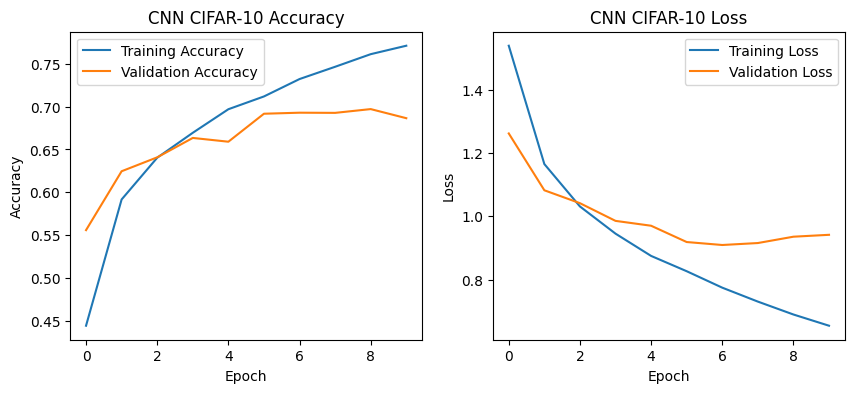

In [ ]:
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train/255.0, x_test/255.0

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, validation_split=0.1)

# ===== Plot history =====
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN CIFAR-10 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN CIFAR-10 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

#Praktikum D5 Transfer Learning dengan Model Pra-Latih

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 386s 274ms/step - accuracy: 0.5191 - loss: 1.3808 - val_accuracy: 0.5642 - val_loss: 1.2418
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 445s 276ms/step - accuracy: 0.5810 - loss: 1.2001 - val_accuracy: 0.5888 - val_loss: 1.1745
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 388s 275ms/step - accuracy: 0.6019 - loss: 1.1423 - val_accuracy: 0.6086 - val_loss: 1.1320
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 384s 273ms/step - accuracy: 0.6147 - loss: 1.1025 - val_accuracy: 0.6148 - val_loss: 1.1118
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 444s 275ms/step - accuracy: 0.6294 - loss: 1.0671 - val_accuracy: 0.6010 - val_loss: 1.1245


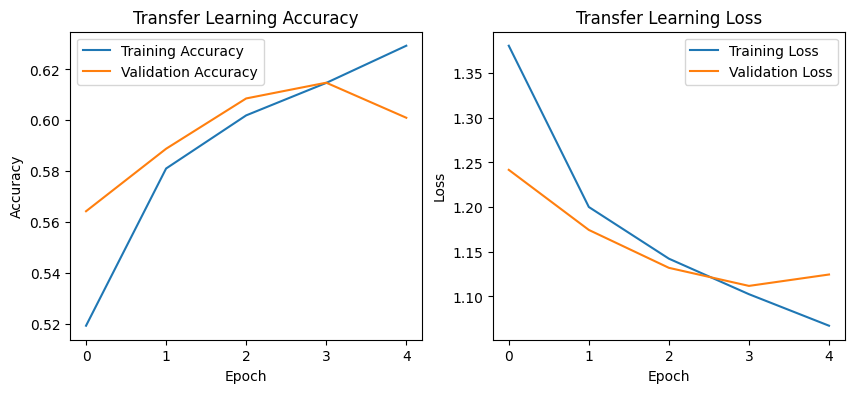

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models # Import models and layers if not already imported from previous cells
import matplotlib.pyplot as plt # Import matplotlib if not already imported from previous cells

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32,32,3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=5, validation_split=0.1)

# ===== Plot history =====
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Transfer Learning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Transfer Learning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Praktikum D6 Evaluasi dengan Confusion Matrix dan Metrik Lain

313/313 ━━━━━━━━━━━━━━━━━━━━ 77s 244ms/step
              precision    recall  f1-score   support

           0       0.60      0.77      0.67      1000
           1       0.61      0.68      0.64      1000
           2       0.66      0.40      0.50      1000
           3       0.43      0.43      0.43      1000
           4       0.49      0.62      0.55      1000
           5       0.64      0.40      0.49      1000
           6       0.59      0.68      0.63      1000
           7       0.68      0.65      0.66      1000
           8       0.77      0.64      0.70      1000
           9       0.57      0.65      0.61      1000

    accuracy                           0.59     10000
   macro avg       0.60      0.59      0.59     10000
weighted avg       0.60      0.59      0.59     10000



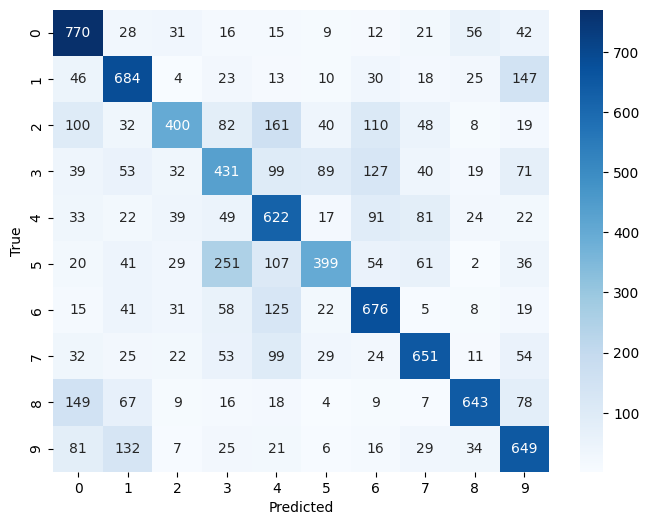

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(x_test).argmax(axis=1)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()